In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# Configuración de gráficos
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

In [2]:
# Funciones auxiliares

def normalizar_datos(X):
    """
    Escala las variables para que tengan
    media cero y desviación estándar unitaria.
    """
    escalador = StandardScaler()
    return escalador.fit_transform(X)


def mostrar_resumen(nombre, datos):
    """
    Imprime información básica del conjunto de datos.
    """
    print("=" * 50)
    print(nombre)
    print("=" * 50)
    print(f"Número de muestras : {datos.shape[0]}")
    print(f"Número de variables: {datos.shape[1]}")
    print()


def graficar_clusters(X, etiquetas, titulo,
                       xlabel="Variable 1",
                       ylabel="Variable 2"):
    """
    Representación bidimensional de los clusters.
    """

    plt.figure(figsize=(8,6))

    plt.scatter(
        X[:,0],
        X[:,1],
        c=etiquetas,
        cmap="tab10",
        s=18,
        alpha=0.75
    )

    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [3]:
# Ejercicio 1 - Agrupamiento con K-Means
# Dataset: Wine

from sklearn.datasets import load_wine

# Cargar el conjunto de datos
wine = load_wine()

# Crear DataFrame para facilitar la exploración
datos = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

mostrar_resumen("Wine Dataset", datos)

datos.head()

Wine Dataset
Número de muestras : 178
Número de variables: 13



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [4]:
# Estadísticas descriptivas
datos.describe().T

# Selección de variables
variables = [
    "alcohol",
    "color_intensity"
]

X = datos[variables].values

X = normalizar_datos(X)

print("Dimensiones:", X.shape)

Dimensiones: (178, 2)


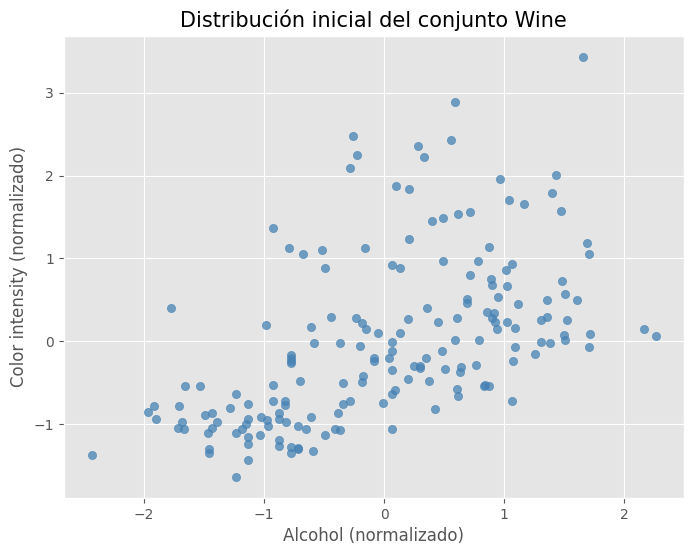

In [5]:
# Distribución de los datos
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    s=35,
    color="steelblue",
    alpha=0.75
)

plt.xlabel("Alcohol (normalizado)")
plt.ylabel("Color intensity (normalizado)")
plt.title("Distribución inicial del conjunto Wine")

plt.show()

In [6]:
# K-Means
from sklearn.cluster import KMeans

modelo_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

etiquetas = modelo_kmeans.fit_predict(X)

print("Centroides encontrados:\n")
print(modelo_kmeans.cluster_centers_)

Centroides encontrados:

[[ 0.40313085  1.65389899]
 [-0.99779866 -0.8442919 ]
 [ 0.75390118  0.06029021]]


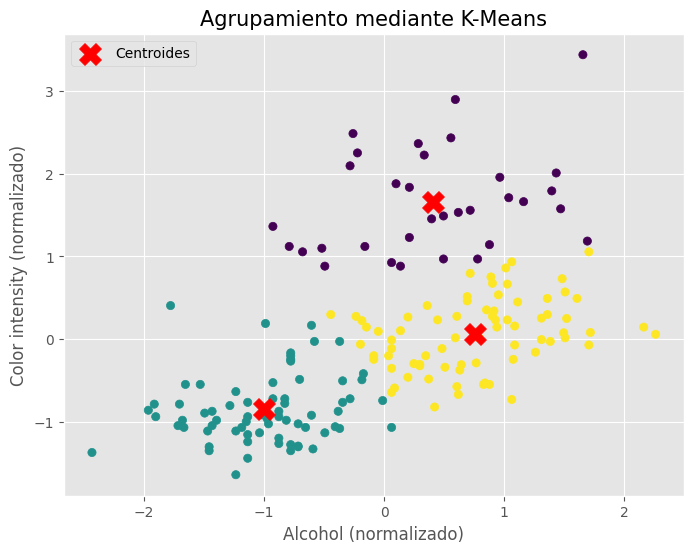

In [7]:
# Visualización de los clusters
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=etiquetas,
    cmap="viridis",
    s=35
)

plt.scatter(
    modelo_kmeans.cluster_centers_[:,0],
    modelo_kmeans.cluster_centers_[:,1],
    c="red",
    s=250,
    marker="X",
    label="Centroides"
)

plt.xlabel("Alcohol (normalizado)")
plt.ylabel("Color intensity (normalizado)")
plt.title("Agrupamiento mediante K-Means")

plt.legend()

plt.show()

In [8]:
from sklearn.metrics import silhouette_score

indice = silhouette_score(X, etiquetas)

print(f"Silhouette Score: {indice:.3f}")

Silhouette Score: 0.466


Digits Dataset
Número de muestras : 1797
Número de variables: 64

Dimensiones: (1797, 64)
Varianza explicada: 21.59%


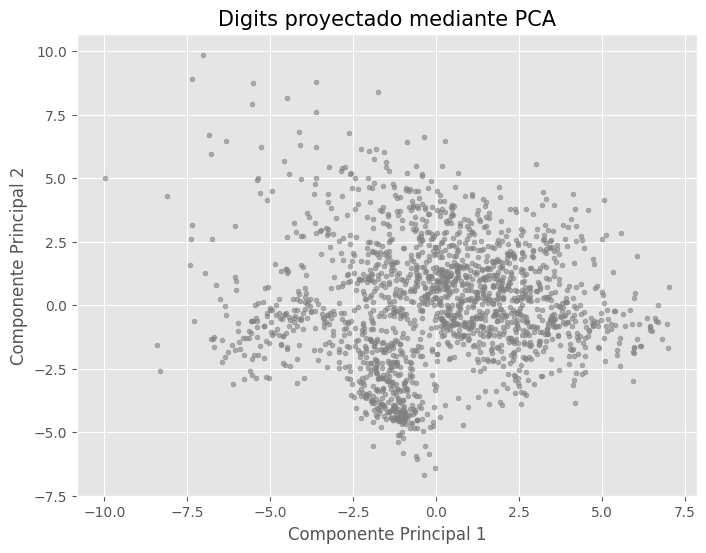

In [10]:
#Bloque de MiniBatch k-means


# Ejercicio 2 - MiniBatch K-Means
# Dataset: Digits

from sklearn.datasets import load_digits

digits = load_digits()

X_digits = digits.data
y_real = digits.target

mostrar_resumen("Digits Dataset", X_digits)

# Escalamiento de los datos
X_digits = normalizar_datos(X_digits)

print("Dimensiones:", X_digits.shape)

# PCA para visualización
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_digits)

print(
    f"Varianza explicada: {pca.explained_variance_ratio_.sum():.2%}"
)

# Datos proyectados mediante PCA
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    s=12,
    alpha=0.60,
    color="gray"
)

plt.title("Digits proyectado mediante PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

Inercia del modelo:
75331.88564107032


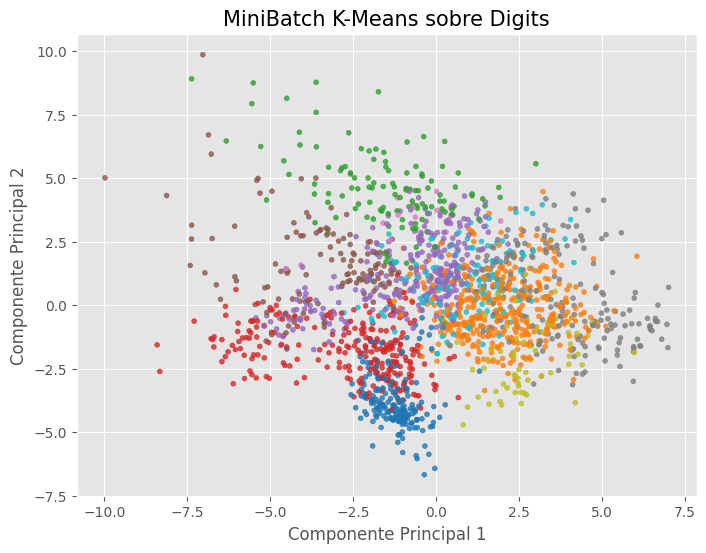

In [11]:
# MiniBatch K-Means
from sklearn.cluster import MiniBatchKMeans

mini_model = MiniBatchKMeans(
    n_clusters=10,
    batch_size=256,
    random_state=42,
    n_init=20
)

labels_mini = mini_model.fit_predict(X_digits)

print("Inercia del modelo:")
print(mini_model.inertia_)

# Visualización del resultado
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels_mini,
    cmap="tab10",
    s=12,
    alpha=0.8
)

plt.title("MiniBatch K-Means sobre Digits")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

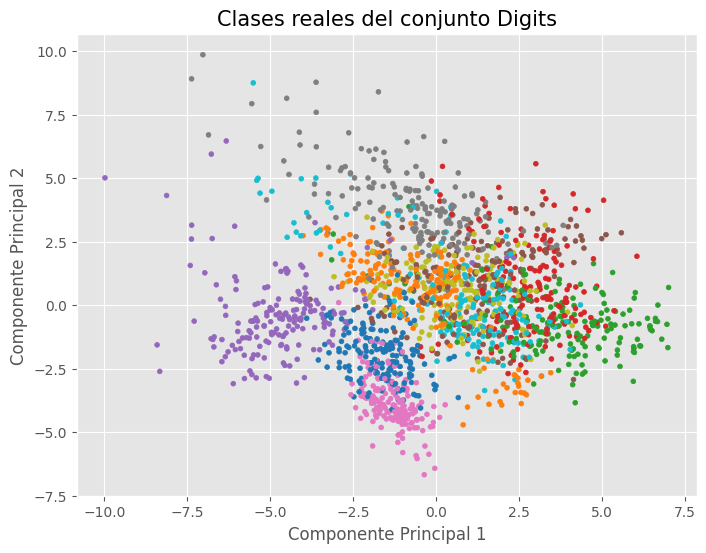

Silhouette Score: 0.108


In [12]:
# Etiquetas reales
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_real,
    cmap="tab10",
    s=12
)

plt.title("Clases reales del conjunto Digits")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()


# Métricas de calidad
from sklearn.metrics import silhouette_score

sil = silhouette_score(
    X_digits,
    labels_mini
)

print(f"Silhouette Score: {sil:.3f}")

In [13]:
# Ejercicio 3 - DBSCAN
# Dataset sintético: Two Moons

from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(
    n_samples=1200,
    noise=0.08,
    random_state=42
)

mostrar_resumen("Two Moons", X_moons)

Two Moons
Número de muestras : 1200
Número de variables: 2



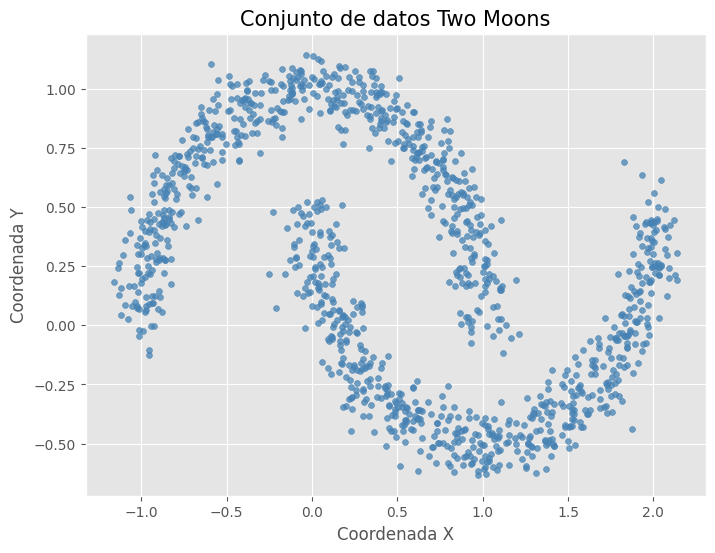

In [14]:
# Distribución original
plt.figure(figsize=(8,6))

plt.scatter(
    X_moons[:,0],
    X_moons[:,1],
    s=18,
    color="steelblue",
    alpha=0.75
)

plt.title("Conjunto de datos Two Moons")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")

plt.show()

Número de clusters encontrados: 2
Puntos considerados ruido: 1


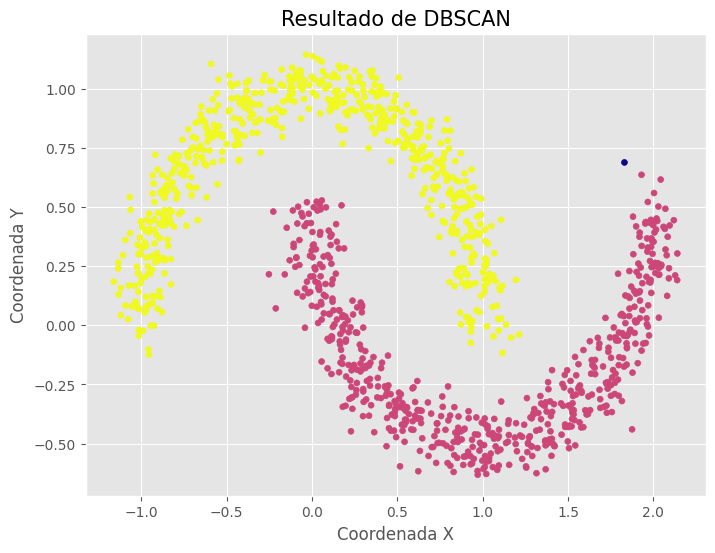

In [15]:
# Entrenamiento del modelo
from sklearn.cluster import DBSCAN

modelo_dbscan = DBSCAN(
    eps=0.18,
    min_samples=8
)

labels_dbscan = modelo_dbscan.fit_predict(X_moons)

print("Número de clusters encontrados:",
      len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0))

print("Puntos considerados ruido:",
      np.sum(labels_dbscan == -1))


# Clusters identificados
plt.figure(figsize=(8,6))

plt.scatter(
    X_moons[:,0],
    X_moons[:,1],
    c=labels_dbscan,
    cmap="plasma",
    s=18
)

plt.title("Resultado de DBSCAN")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")

plt.show()

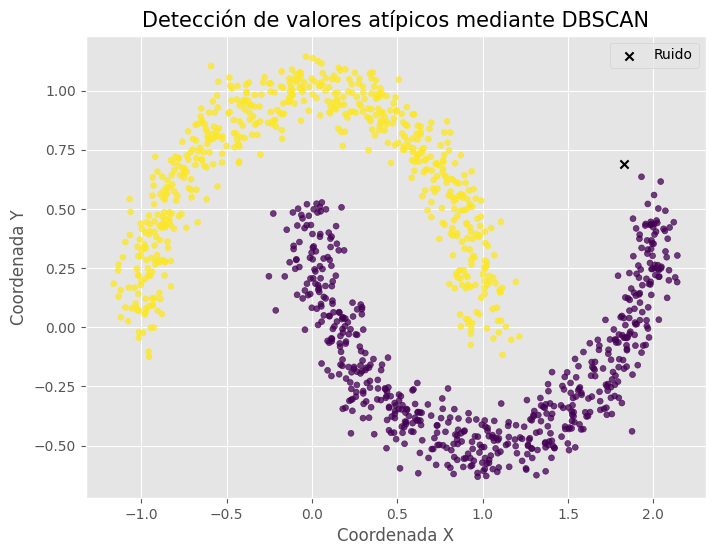

In [ ]:
# Identificación del ruido
plt.figure(figsize=(8,6))

# Clusters
plt.scatter(
    X_moons[labels_dbscan != -1,0],
    X_moons[labels_dbscan != -1,1],
    c=labels_dbscan[labels_dbscan != -1],
    cmap="viridis",
    s=18,
    alpha=0.75
)

# Ruido
plt.scatter(
    X_moons[labels_dbscan == -1,0],
    X_moons[labels_dbscan == -1,1],
    color="black",
    marker="x",
    s=35,
    label="Ruido"
)

plt.title("Detección de valores atípicos mediante DBSCAN")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")
plt.legend()

plt.show()

In [17]:
# Evaluación del modelo
from sklearn.metrics import silhouette_score

mascara = labels_dbscan != -1

if len(np.unique(labels_dbscan[mascara])) > 1:

    score = silhouette_score(
        X_moons[mascara],
        labels_dbscan[mascara]
    )

    print(f"Silhouette Score: {score:.3f}")

else:

    print("No existen suficientes clusters para calcular la métrica.")

Silhouette Score: 0.329


Breast Cancer Dataset
Número de muestras : 569
Número de variables: 30

(569, 30)
Varianza explicada: 63.24%


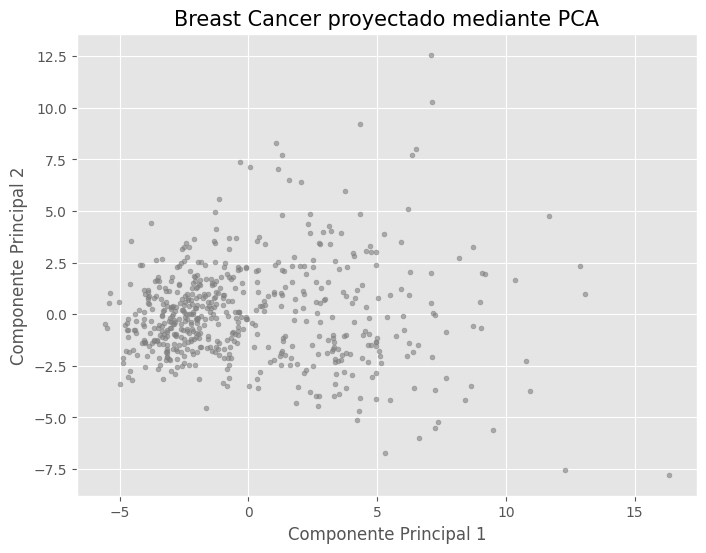

In [24]:
#Bloque HBDSCAN

# Cargar el conjunto de datos
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

datos_cancer = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

mostrar_resumen("Breast Cancer Dataset", datos_cancer)

# Normalizar los datos
X_cancer = normalizar_datos(datos_cancer.values)

print(X_cancer.shape)

# Reducir la dimensionalidad
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_cancer_pca = pca.fit_transform(X_cancer)

print(
    f"Varianza explicada: {pca.explained_variance_ratio_.sum():.2%}"
)

# Visualizar la distribución
plt.figure(figsize=(8,6))

plt.scatter(
    X_cancer_pca[:,0],
    X_cancer_pca[:,1],
    s=12,
    color="gray",
    alpha=0.6
)

plt.title("Breast Cancer proyectado mediante PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

Clusters encontrados: 2
Puntos considerados ruido: 322


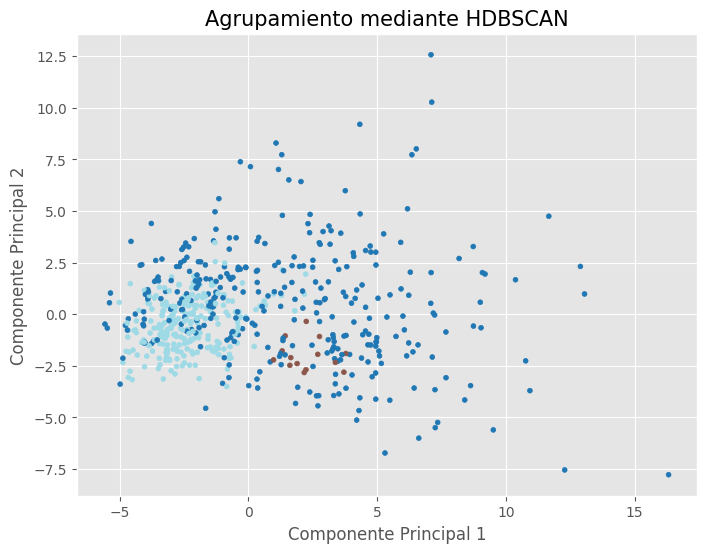

In [25]:
# Entrenar HDBSCAN
import hdbscan

modelo_hdb = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=3
)

labels_hdb = modelo_hdb.fit_predict(X_cancer)

print("Clusters encontrados:",
      len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0))

print("Puntos considerados ruido:",
      np.sum(labels_hdb == -1))


# Visualizar el agrupamiento
plt.figure(figsize=(8,6))

plt.scatter(
    X_cancer_pca[:,0],
    X_cancer_pca[:,1],
    c=labels_hdb,
    cmap="tab20",
    s=12
)

plt.title("Agrupamiento mediante HDBSCAN")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

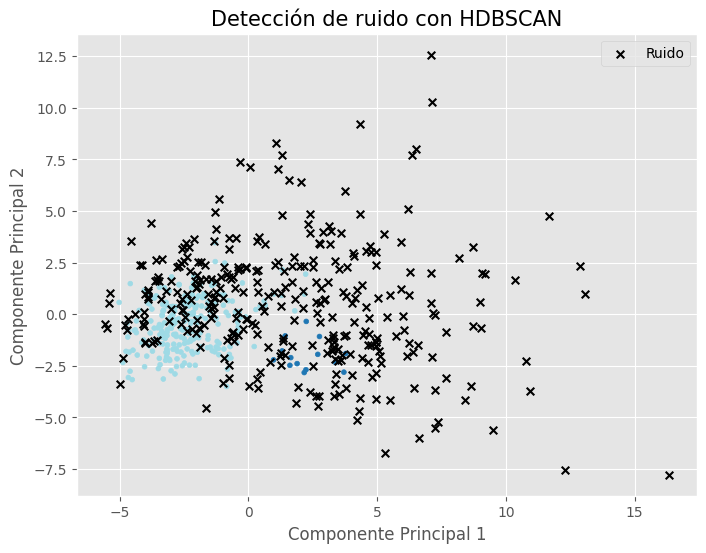

Silhouette Score: 0.344


In [26]:
# Resaltar el ruido
mask = labels_hdb != -1

plt.figure(figsize=(8,6))

plt.scatter(
    X_cancer_pca[mask,0],
    X_cancer_pca[mask,1],
    c=labels_hdb[mask],
    cmap="tab20",
    s=12
)

plt.scatter(
    X_cancer_pca[~mask,0],
    X_cancer_pca[~mask,1],
    color="black",
    marker="x",
    s=30,
    label="Ruido"
)

plt.legend()

plt.title("Detección de ruido con HDBSCAN")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

# Evaluar el agrupamiento
from sklearn.metrics import silhouette_score

mask = labels_hdb != -1

if np.unique(labels_hdb[mask]).size > 1:

    score = silhouette_score(
        X_cancer[mask],
        labels_hdb[mask]
    )

    print(f"Silhouette Score: {score:.3f}")

else:

    print("No hay suficientes clusters para calcular la métrica.")

Iris Dataset
Número de muestras : 150
Número de variables: 4

(150, 4)
Varianza explicada: 95.81%


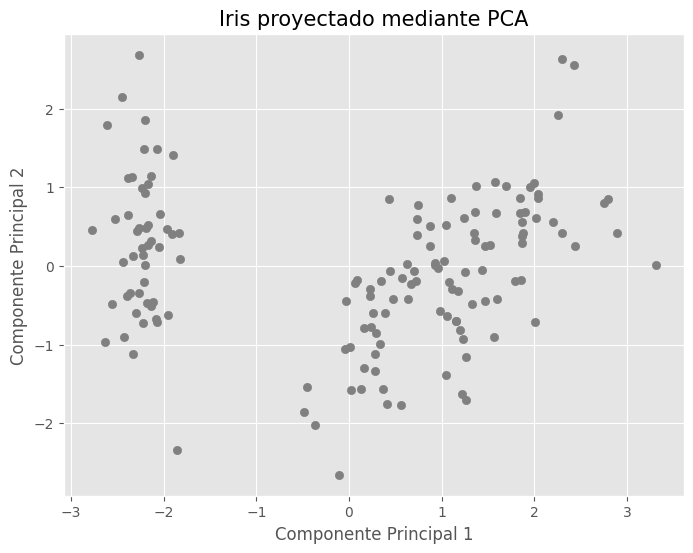

In [27]:
#Bloque de Ward Linkage 

# Cargar el conjunto de datos

from sklearn.datasets import load_iris

iris = load_iris()

datos_iris = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

mostrar_resumen("Iris Dataset", datos_iris)

# Normalizar los datos

X_iris = normalizar_datos(datos_iris.values)

print(X_iris.shape)

# Reducir la dimensionalidad

from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_iris_pca = pca.fit_transform(X_iris)

print(
    f"Varianza explicada: {pca.explained_variance_ratio_.sum():.2%}"
)

# Visualizar la distribución

plt.figure(figsize=(8,6))

plt.scatter(
    X_iris_pca[:,0],
    X_iris_pca[:,1],
    color="gray",
    s=35
)

plt.title("Iris proyectado mediante PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

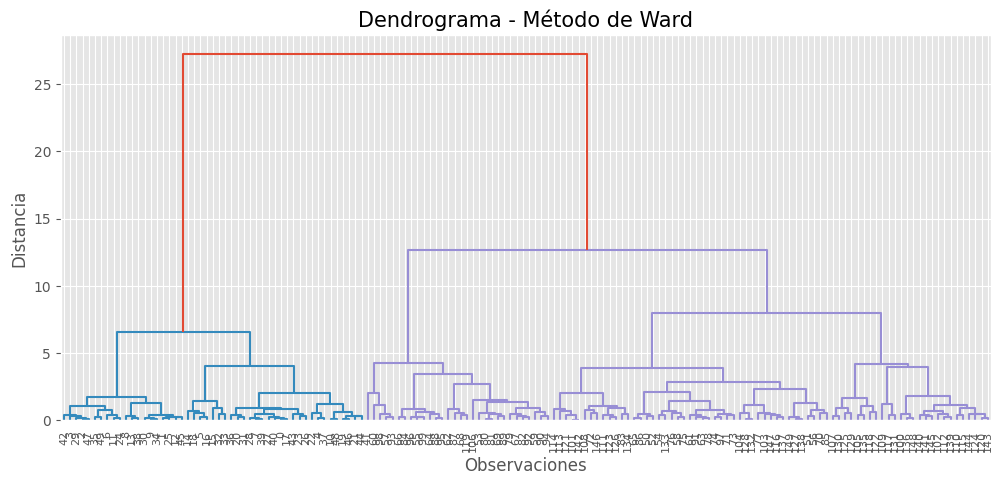

In [28]:
# Construir el dendrograma

from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(
    X_iris,
    method="ward"
)

plt.figure(figsize=(12,5))

dendrogram(
    Z,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Dendrograma - Método de Ward")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")

plt.show()

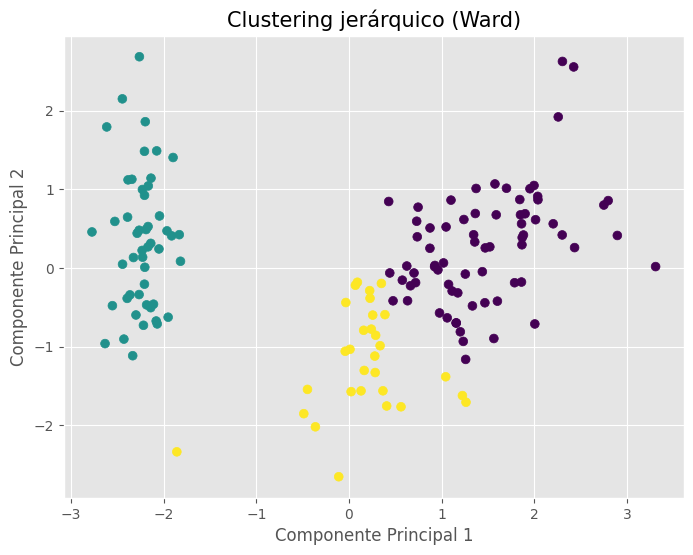

In [30]:
# Entrenar el modelo

from sklearn.cluster import AgglomerativeClustering

modelo_ward = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

labels_ward = modelo_ward.fit_predict(X_iris)

# Visualizar los clusters

plt.figure(figsize=(8,6))

plt.scatter(
    X_iris_pca[:,0],
    X_iris_pca[:,1],
    c=labels_ward,
    cmap="viridis",
    s=40
)

plt.title("Clustering jerárquico (Ward)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

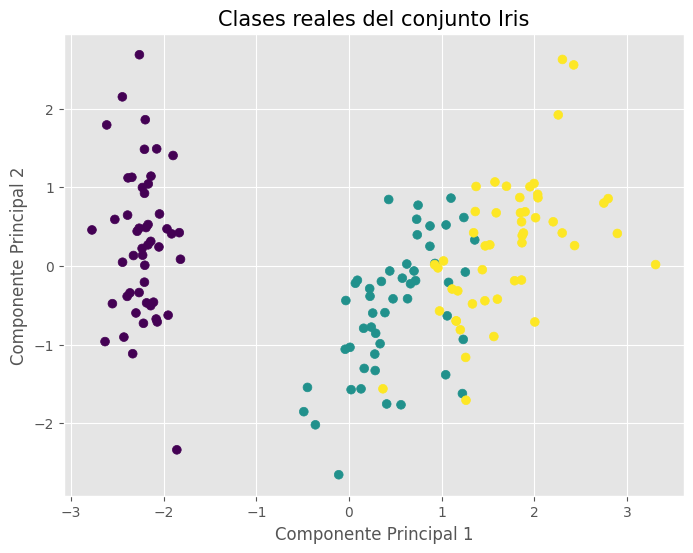

Silhouette Score: 0.447


In [31]:
# Comparar con las etiquetas reales

plt.figure(figsize=(8,6))

plt.scatter(
    X_iris_pca[:,0],
    X_iris_pca[:,1],
    c=iris.target,
    cmap="viridis",
    s=40
)

plt.title("Clases reales del conjunto Iris")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

# Evaluar el agrupamiento

from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_iris,
    labels_ward
)

print(f"Silhouette Score: {score:.3f}")

Wine Dataset (BIRCH)
Número de muestras : 178
Número de variables: 13

(178, 13)
Varianza explicada: 55.41%


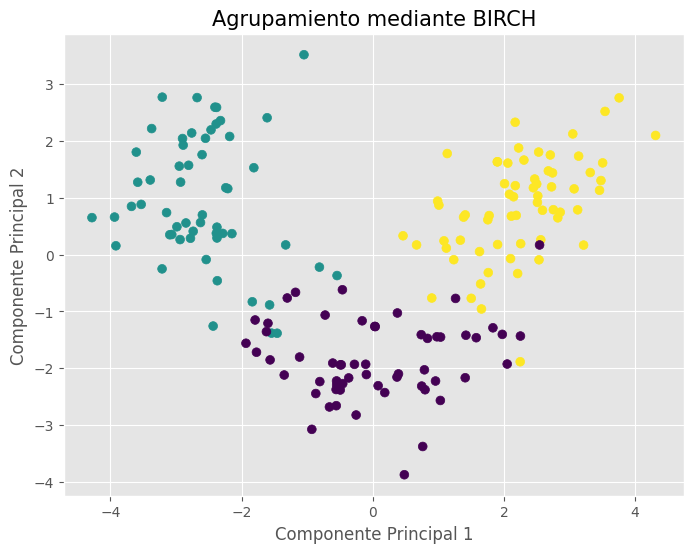

In [32]:
#Bloque BIRCH

# Cargar el conjunto de datos

from sklearn.datasets import load_wine

wine = load_wine()

datos_wine = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

mostrar_resumen("Wine Dataset (BIRCH)", datos_wine)

# Normalizar los datos

X_wine = normalizar_datos(datos_wine.values)

print(X_wine.shape)

# Reducir la dimensionalidad

from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_wine_pca = pca.fit_transform(X_wine)

print(
    f"Varianza explicada: {pca.explained_variance_ratio_.sum():.2%}"
)

# Entrenar BIRCH

from sklearn.cluster import Birch

modelo_birch = Birch(
    n_clusters=3,
    threshold=0.5
)

labels_birch = modelo_birch.fit_predict(X_wine)

# Visualizar los clusters

plt.figure(figsize=(8,6))

plt.scatter(
    X_wine_pca[:,0],
    X_wine_pca[:,1],
    c=labels_birch,
    cmap="viridis",
    s=40
)

plt.title("Agrupamiento mediante BIRCH")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

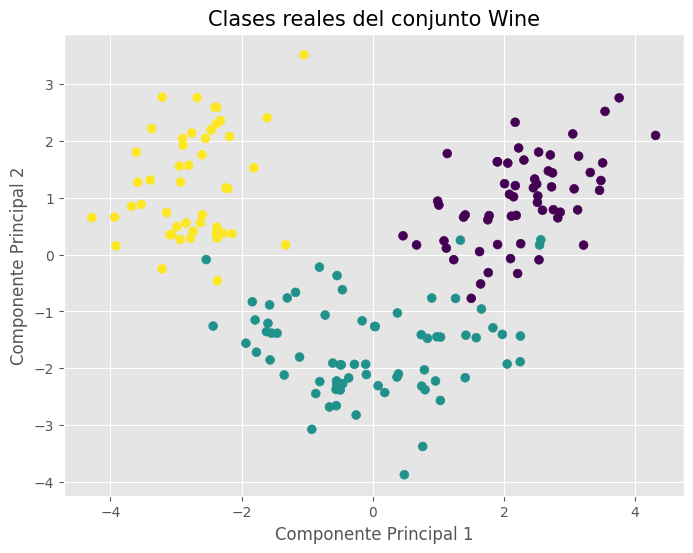

Silhouette Score: 0.277


In [33]:
# Comparar con las clases reales

plt.figure(figsize=(8,6))

plt.scatter(
    X_wine_pca[:,0],
    X_wine_pca[:,1],
    c=wine.target,
    cmap="viridis",
    s=40
)

plt.title("Clases reales del conjunto Wine")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

# Evaluar el agrupamiento

from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_wine,
    labels_birch
)

print(f"Silhouette Score: {score:.3f}")

(1797, 64)
Varianza explicada: 21.59%


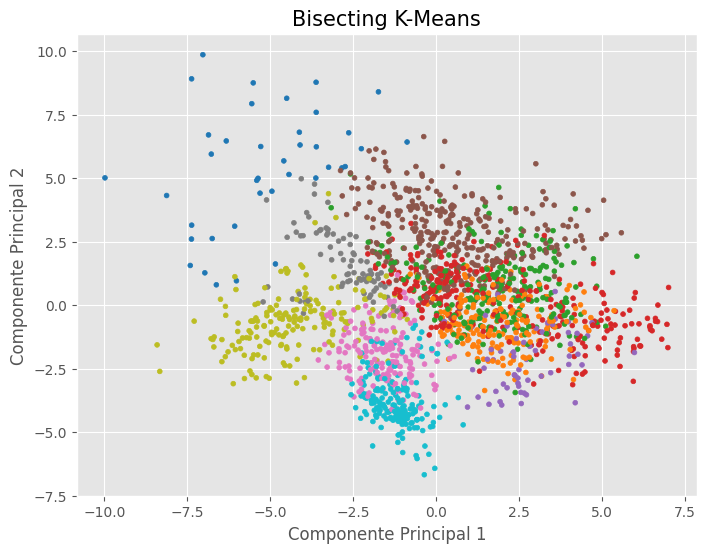

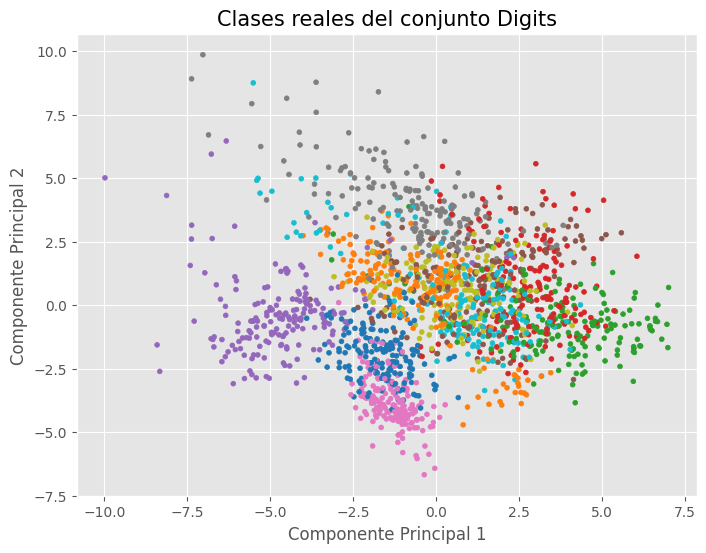

Silhouette Score: 0.108


In [34]:
#Bloque Bisecting K-Means

# Cargar el conjunto de datos

from sklearn.datasets import load_digits

digits = load_digits()

X_digits = normalizar_datos(digits.data)

print(X_digits.shape)

# Reducir la dimensionalidad

from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_digits_pca = pca.fit_transform(X_digits)

print(
    f"Varianza explicada: {pca.explained_variance_ratio_.sum():.2%}"
)

# Entrenar Bisecting K-Means

from sklearn.cluster import BisectingKMeans

modelo_bisect = BisectingKMeans(
    n_clusters=10,
    random_state=42
)

labels_bisect = modelo_bisect.fit_predict(X_digits)

# Visualizar los clusters

plt.figure(figsize=(8,6))

plt.scatter(
    X_digits_pca[:,0],
    X_digits_pca[:,1],
    c=labels_bisect,
    cmap="tab10",
    s=12
)

plt.title("Bisecting K-Means")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

# Comparar con las etiquetas reales

plt.figure(figsize=(8,6))

plt.scatter(
    X_digits_pca[:,0],
    X_digits_pca[:,1],
    c=digits.target,
    cmap="tab10",
    s=12
)

plt.title("Clases reales del conjunto Digits")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

# Evaluar el agrupamiento

from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_digits,
    labels_bisect
)

print(f"Silhouette Score: {score:.3f}")

In [35]:
from sklearn.cluster import BisectingKMeans